# ЛР 2

## Импорты

In [ ]:
!pip install numpy scikit-learn matplotlib ipykernel
!pip install torch==2.3.1+rocm5.7 torchvision==0.18.1+rocm5.7 --index-url https://download.pytorch.org/whl/rocm5.7

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as transforms

## Загрузка и предобработка данных MNIST

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

X_train = train_dataset.data.numpy().reshape(-1, 28*28) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 28*28) / 255.0
y_test = test_dataset.targets.numpy()

X_test = X_test[:10000]
y_test = y_test[:10000]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



## Обучение MLP из scikit-learn

In [3]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', 
                    solver='adam', max_iter=50, batch_size=128, 
                    random_state=42, verbose=True)
mlp.fit(X_train_scaled, y_train)

Iteration 1, loss = 0.23596848
Iteration 2, loss = 0.09153882
Iteration 3, loss = 0.05718661
Iteration 4, loss = 0.03963499
Iteration 5, loss = 0.03374591
Iteration 6, loss = 0.02725932
Iteration 7, loss = 0.02394292
Iteration 8, loss = 0.02134081
Iteration 9, loss = 0.01384271
Iteration 10, loss = 0.01900673
Iteration 11, loss = 0.01767222
Iteration 12, loss = 0.01990630
Iteration 13, loss = 0.01601808
Iteration 14, loss = 0.01507100
Iteration 15, loss = 0.01418411
Iteration 16, loss = 0.00912663
Iteration 17, loss = 0.00889015
Iteration 18, loss = 0.01611486
Iteration 19, loss = 0.01159628
Iteration 20, loss = 0.01647564
Iteration 21, loss = 0.01445717
Iteration 22, loss = 0.00940093
Iteration 23, loss = 0.00844438
Iteration 24, loss = 0.00885527
Iteration 25, loss = 0.00986860
Iteration 26, loss = 0.01095847
Iteration 27, loss = 0.01591309
Iteration 28, loss = 0.01203507
Iteration 29, loss = 0.00881338
Iteration 30, loss = 0.00974011
Iteration 31, loss = 0.01312932
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",128
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [4]:
y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average='macro')
rec_mlp = recall_score(y_test, y_pred_mlp, average='macro')
f1_mlp = f1_score(y_test, y_pred_mlp, average='macro')

print("MLP Results:")
print(f"Accuracy:  {acc_mlp:.4f}")
print(f"Precision: {prec_mlp:.4f}")
print(f"Recall:    {rec_mlp:.4f}")
print(f"F1-score:  {f1_mlp:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_mlp))

MLP Results:
Accuracy:  0.9754
Precision: 0.9753
Recall:    0.9752
F1-score:  0.9752

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.99      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Подготовка данных для PyTorch CNN

In [5]:
X_train_cnn = X_train.reshape(-1, 1, 28, 28)
X_test_cnn = X_test.reshape(-1, 1, 28, 28)

tensor_x_train = torch.tensor(X_train_cnn, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.long)
tensor_x_test = torch.tensor(X_test_cnn, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(tensor_x_train, tensor_y_train)
test_dataset = TensorDataset(tensor_x_test, tensor_y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Архитектура CNN (LeNet-5)

In [6]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

## Обучение CNN

Epoch 1/15 - Loss: 0.3002
Epoch 2/15 - Loss: 0.0897
Epoch 3/15 - Loss: 0.0619
Epoch 4/15 - Loss: 0.0479
Epoch 5/15 - Loss: 0.0392
Epoch 6/15 - Loss: 0.0328
Epoch 7/15 - Loss: 0.0269
Epoch 8/15 - Loss: 0.0228
Epoch 9/15 - Loss: 0.0204
Epoch 10/15 - Loss: 0.0172
Epoch 11/15 - Loss: 0.0160
Epoch 12/15 - Loss: 0.0129
Epoch 13/15 - Loss: 0.0117
Epoch 14/15 - Loss: 0.0101
Epoch 15/15 - Loss: 0.0094


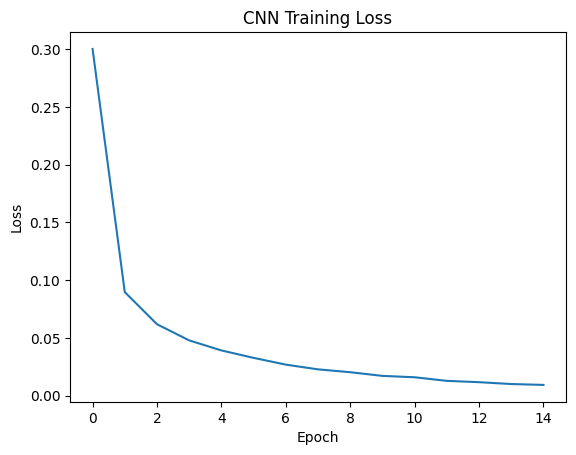

In [7]:
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

plt.plot(train_losses)
plt.title('CNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [8]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc_cnn = accuracy_score(all_labels, all_preds)
prec_cnn = precision_score(all_labels, all_preds, average='macro')
rec_cnn = recall_score(all_labels, all_preds, average='macro')
f1_cnn = f1_score(all_labels, all_preds, average='macro')

print("CNN (LeNet-5) Results:")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1-score:  {f1_cnn:.4f}")
print("\nClassification report:\n", classification_report(all_labels, all_preds))

CNN (LeNet-5) Results:
Accuracy:  0.9870
Precision: 0.9869
Recall:    0.9869
F1-score:  0.9869

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Сравнение моделей

In [9]:
print("\n" + "="*50)
print("Сравнение MLP и CNN на тестовой выборке MNIST")
print("="*50)
print(f"{'Метрика':<15} {'MLP':<10} {'CNN (LeNet-5)':<15}")
print("-"*40)
print(f"{'Accuracy':<15} {acc_mlp:<10.4f} {acc_cnn:<15.4f}")
print(f"{'Precision':<15} {prec_mlp:<10.4f} {prec_cnn:<15.4f}")
print(f"{'Recall':<15} {rec_mlp:<10.4f} {rec_cnn:<15.4f}")
print(f"{'F1-score':<15} {f1_mlp:<10.4f} {f1_cnn:<15.4f}")


Сравнение MLP и CNN на тестовой выборке MNIST
Метрика         MLP        CNN (LeNet-5)  
----------------------------------------
Accuracy        0.9754     0.9870         
Precision       0.9753     0.9869         
Recall          0.9752     0.9869         
F1-score        0.9752     0.9869         


## Выводы
1. Сверточная сеть показала статистически значимое превосходство над полносвязным MLP.
Прирост accuracy с 97.54% до 98.70% означает сокращение ошибки с 2.46% до 1.30%, что для MNIST является существенным улучшением.

2. CNN лучше справляется со сложными для MLP классами.
Например, для цифры "2" precision MLP = 0.96, recall = 0.97, а у CNN оба показателя 0.99;
для цифры "3" recall MLP 0.97 - CNN 0.99;
для цифры "5" precision MLP 0.97 - CNN 0.99.
Это объясняется способностью сверточных фильтров улавливать локальные формы и структуры, а не просто отдельные пиксели.

3. Архитектурное смещение (inductive bias) CNN оправдывает себя.
- Сверточные слои используют разделяемые веса, что резко сокращает число параметров и помогает выделять признаки инвариантно к сдвигу.
- Операции подвыборки (AvgPool) добавляют локальную инвариантность к малым искажениям.
- MLP же рассматривает изображение как одномерный вектор и вынужден заново учить одни и те же признаки в разных частях картинки, что ограничивает его обобщающую способность.

4. Общее заключение.
Даже на относительно простом датасете MNIST (чёрно-белые рукописные цифры) сверточная нейронная сеть (LeNet-5) превосходит многослойный перцептрон по всем ключевым метрикам. Это подтверждает фундаментальную роль пространственной иерархии признаков в задачах компьютерного зрения и объясняет, почему CNN стали стандартом для анализа изображений.